In [1]:
import re
import sys
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
def extract_species_and_time(log_file):
    """
    Extracts species name and total runtime (user + sys) from the log file.

    :param log_file: Path to the log file.
    :return: Dictionary with species as the key and total runtime (in seconds) as the value.
    """
    species_pattern = re.compile(r'/species/([\w.]+)/')
    user_time_pattern = re.compile(r'user\s+(\d+)m([\d.]+)s')
    sys_time_pattern = re.compile(r'sys\s+(\d+)m([\d.]+)s')

    species = None
    user_time = 0
    sys_time = 0

    with open(log_file, 'r', encoding='utf-8') as file:
        for line in file:
            # Extract species from --species flag
            species_match = species_pattern.search(line)
            if species_match:
                species = species_match.group(1)
                species = species.split('.')[0]

            # Extract user time
            user_match = user_time_pattern.search(line)
            if user_match:
                user_time = int(user_match.group(1)) * 60 + float(user_match.group(2))

            # Extract sys time
            sys_match = sys_time_pattern.search(line)
            if sys_match:
                sys_time = int(sys_match.group(1)) * 60 + float(sys_match.group(2))

    if species and (user_time or sys_time):
        total_time = user_time + sys_time
        result = {'species' : species,
                'sec': round(total_time, 3),
                'min': round(total_time, 3)/60}
        return result
    else:
        print(f"Could not extract species name or runtime from {species}.")
        result = {'species' : species,
                'sec': np.nan,
                'min': np.nan}
        return result

In [3]:
aug_df = pd.DataFrame()
jobs = ! realpath ../results/running_time/drosophila/augustus//*

for i in jobs:
    d = extract_species_and_time(i)
    aug_df = pd.concat([aug_df, pd.DataFrame([d])], ignore_index=True)
aug_df['tool'] = 'augustus'

In [4]:
geneid_df = pd.DataFrame()
jobs = ! realpath ../results/running_time/drosophila/geneid/*

for i in jobs:
    d = extract_species_and_time(i)
    geneid_df = pd.concat([geneid_df, pd.DataFrame([d])], ignore_index=True)
geneid_df['tool'] = 'geneid'

In [5]:
helix_df = pd.DataFrame()
jobs = ! realpath ../results/running_time/drosophila/helixer//*

for i in jobs:
    d = extract_species_and_time(i)
    helix_df = pd.concat([helix_df, pd.DataFrame([d])], ignore_index=True)
helix_df['tool'] = 'helixer_CPU'

In [7]:
helixGPU_df = pd.DataFrame()
jobs = ! realpath ../results/running_time/drosophila/helixer_GPU/*

for i in jobs:
    d = extract_species_and_time(i)
    helixGPU_df = pd.concat([helixGPU_df, pd.DataFrame([d])], ignore_index=True)
helixGPU_df['tool'] = 'helixer_GPU'

In [8]:
helixGPU_df

,species,sec,min,tool
0,Drosophila_ananassae,2482.409,41.373483,helixer_GPU
1,Drosophila_willistoni,2752.229,45.870483,helixer_GPU
2,Musca_domestica,12969.338,216.155633,helixer_GPU
3,Drosophila_erecta,1789.220,29.820333,helixer_GPU
4,Drosophila_ficusphila,2662.622,44.377033,helixer_GPU
5,Drosophila_grimshawi,2803.199,46.719983,helixer_GPU
6,Drosophila_melanogaster,2831.954,47.199233,helixer_GPU
7,Drosophila_miranda,3616.786,60.279767,helixer_GPU
8,Drosophila_persimilis,2378.114,39.635233,helixer_GPU
9,Drosophila_pseudoobscura,1911.909,31.865150,helixer_GPU


In [9]:
df = pd.concat([aug_df, geneid_df,helix_df, helixGPU_df])

In [10]:
dataset = [
    'Drosophila_melanogaster',
    'Drosophila_erecta',
    'Drosophila_simulans',
    'Drosophila_ananassae',
    'Drosophila_ficusphila',
    'Drosophila_miranda',
    'Drosophila_persimilis',
    'Drosophila_pseudoobscura',
    'Drosophila_willistoni',
    'Drosophila_grimshawi',
    'Drosophila_virilis',
    'Musca_domestica'
]

In [11]:
def get_species(x):
    return x.split('/')[2].split('.')[0]

In [12]:
assemblies_size = pd.read_csv('../data/dro_meta/assemblies_size.tsv', sep = '\t', names=['species','size'])
assemblies_size.species = assemblies_size.species.map(get_species)

In [13]:
df = df.merge(assemblies_size, on = 'species')
df = df.dropna()

In [14]:
df

,species,sec,min,tool,size
0,Drosophila_ananassae,28027.789,467.129817,augustus,213817545
1,Drosophila_willistoni,30649.818,510.830300,augustus,246985538
2,Drosophila_erecta,18546.662,309.111033,augustus,146538397
3,Drosophila_ficusphila,20610.906,343.515100,augustus,167832931
4,Drosophila_grimshawi,23926.271,398.771183,augustus,191382978
5,Drosophila_melanogaster,17968.913,299.481883,augustus,143706478
6,Drosophila_miranda,37371.305,622.855083,augustus,287096000
7,Drosophila_persimilis,24461.378,407.689633,augustus,195512972
8,Drosophila_pseudoobscura,21450.923,357.515383,augustus,163266851
9,Drosophila_simulans,16499.199,274.986650,augustus,131663590


<Axes: xlabel='size', ylabel='min'>

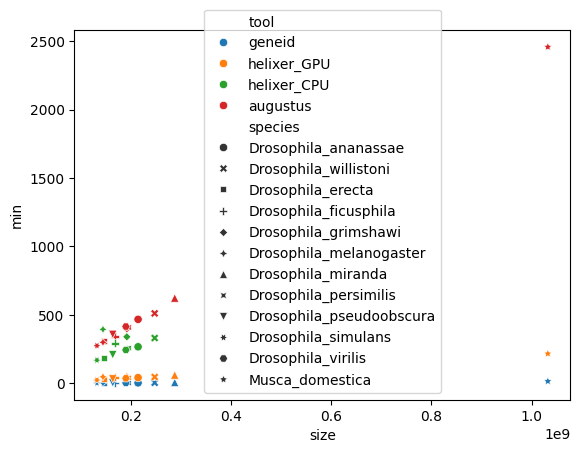

In [15]:
sns.scatterplot(data = df.dropna(),
               x = 'size', 
               y = 'min', 
               hue = 'tool',
               style = 'species',
               hue_order = ['geneid','helixer_GPU', 'helixer_CPU', 'augustus']
               )

<Axes: xlabel='size', ylabel='min'>

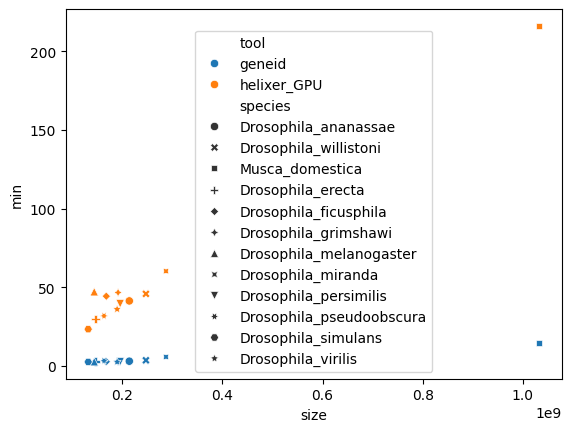

In [16]:
sns.scatterplot(data = df[df.tool.isin(['geneid','helixer_GPU'])].dropna(),
               x = 'size', 
               y = 'min', 
               hue = 'tool',
               style = 'species',
               )